# Project 1: Automatic Review Analyzer

This notebook applies the Unit 1 linear-classification ideas to the complete 3,000-sentence UCI Sentiment Labelled Sentences dataset.

Workflow: **reviews → reproducible split → sparse `X` + `y` → controlled comparison → lambda selection → final test comparison → word weights.**

In [9]:
from pathlib import Path
import sys
import time
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'project_1':
    candidate = PROJECT_DIR / 'unit_1' / 'project_1'
    if candidate.exists():
        PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from linear_classification import accuracy, average_perceptron, pegasos, perceptron
from review_data import prepare_review_data, tokenize

## 1. Dataset and reproducible split

The dataset contains 1,000 IMDb, 1,000 Amazon, and 1,000 Yelp sentences: 3,000 reviews total, balanced between positive and negative labels. A fixed seed gives a stratified 70/15/15 split. The test set remains untouched until final evaluation.

In [10]:
SEED = 42
data = prepare_review_data(PROJECT_DIR, seed=SEED, min_count=2)
reviews = data['reviews']
train_reviews = data['train_reviews']
validation_reviews = data['validation_reviews']
test_reviews = data['test_reviews']
vocabulary = data['vocabulary']
X_train, y_train = data['X_train'], data['y_train']
X_validation, y_validation = data['X_validation'], data['y_validation']
X_test, y_test = data['X_test'], data['y_test']
train_data = list(zip(y_train, X_train))
validation_data = list(zip(y_validation, X_validation))
test_data = list(zip(y_test, X_test))

print(f'Total: {len(reviews)} | Positive: {sum(r[0] == 1 for r in reviews)} | Negative: {sum(r[0] == -1 for r in reviews)}')
print(f'Train: {len(train_data)} | Validation: {len(validation_data)} | Test: {len(test_data)}')
print(f'Vocabulary: {len(vocabulary)}')

Total: 3000 | Positive: 1500 | Negative: 1500
Train: 2100 | Validation: 450 | Test: 450
Vocabulary: 1766


## 2. Review text → sparse `X` and `y`

Review-specific tokenization, vocabulary construction, and vectorization live in `review_data.py`. The vocabulary is learned from training reviews only, then reused for validation and test reviews. The representation is a sparse binary bag of words.

In [11]:
print('Example tokens:', tokenize(train_reviews[0][1])[:12])
print('Example sparse vector:', list(X_train[0].items())[:10])
print('X_train:', len(X_train), '| y_train:', len(y_train))

Example tokens: ['car', 'charger', 'as', 'well', 'as', 'ac', 'charger', 'are', 'included', 'to', 'make', 'sure']
Example sparse vector: [(89, 1.0), (1567, 1.0), (1757, 1.0), (1485, 1.0), (1047, 1.0), (1691, 1.0), (267, 1.0), (97, 1.0), (931, 1.0), (841, 1.0)]
X_train: 2100 | y_train: 2100


## 3. Controlled comparison

This asks how the three learning rules compare with the same training data and epoch budget. Pegasos uses fixed `lambda_=1e-3` here. This experiment is intentionally separate from later tuning.

In [12]:
EPOCHS = 10
BATCH_SIZE = 32
FIXED_LAMBDA = 1e-3

def timed(train_fn):
    start = time.perf_counter()
    weights = train_fn()
    return weights, time.perf_counter() - start

specs = {
    'Perceptron': lambda: perceptron(train_data, epochs=EPOCHS),
    'Average Perceptron': lambda: average_perceptron(train_data, epochs=EPOCHS),
    'Pegasos (lambda=1e-3)': lambda: pegasos(train_data, lambda_=FIXED_LAMBDA, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED),
}
controlled_models = {}
for name, train_fn in specs.items():
    weights, elapsed = timed(train_fn)
    controlled_models[name] = weights
    print(f'{name:25} | {elapsed:.4f}s | validation={accuracy(weights, validation_data):.2%}')

Perceptron                | 0.1274s | validation=75.11%
Average Perceptron        | 0.1706s | validation=78.89%
Pegasos (lambda=1e-3)     | 0.4638s | validation=79.56%


## 4. Pegasos hyperparameter selection

Select the regularization value using validation accuracy only.

$$
\lambda^*=\arg\max_{\lambda}\mathrm{ValidationAccuracy}(\lambda).
$$

If several candidates tie, the smallest value is selected.

In [13]:
lambda_candidates = [1e-6, 1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1]
lambda_results = []
for lambda_ in lambda_candidates:
    weights, elapsed = timed(lambda: pegasos(train_data, lambda_=lambda_, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED))
    score = accuracy(weights, validation_data)
    lambda_results.append((lambda_, score, elapsed, weights))
    print(f'lambda={lambda_:8.1e} | validation={score:.2%} | time={elapsed:.4f}s')
best_score = max(row[1] for row in lambda_results)
best_lambda = min(row[0] for row in lambda_results if row[1] == best_score)
print(f'\nSelected lambda*: {best_lambda:.1e} | validation accuracy={best_score:.2%}')

lambda= 1.0e-06 | validation=56.89% | time=0.5917s
lambda= 1.0e-05 | validation=75.78% | time=0.6051s
lambda= 1.0e-04 | validation=74.44% | time=0.4423s
lambda= 5.0e-04 | validation=78.89% | time=0.4178s
lambda= 1.0e-03 | validation=79.56% | time=0.5953s
lambda= 5.0e-03 | validation=82.89% | time=0.6215s
lambda= 1.0e-02 | validation=82.44% | time=0.6470s
lambda= 5.0e-02 | validation=75.11% | time=0.5544s
lambda= 1.0e-01 | validation=71.56% | time=0.6038s
lambda= 5.0e-01 | validation=70.22% | time=0.5522s

Selected lambda*: 5.0e-03 | validation accuracy=82.89%


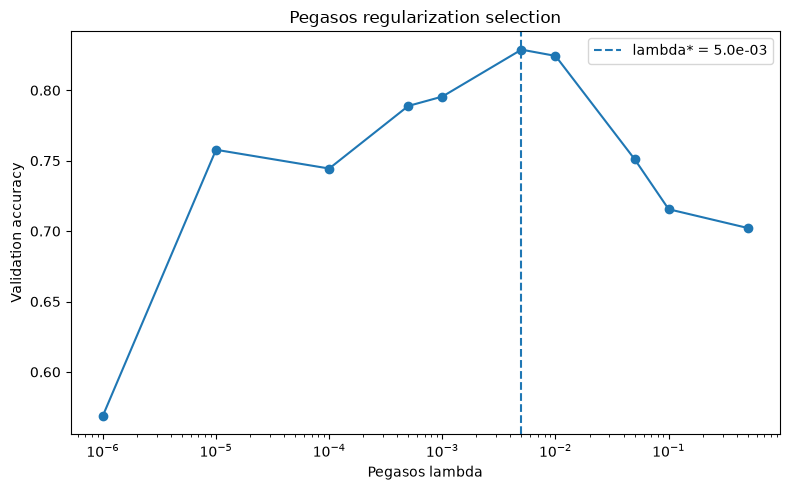

In [14]:
plt.figure(figsize=(8, 5))
plt.semilogx([r[0] for r in lambda_results], [r[1] for r in lambda_results], marker='o')
plt.axvline(best_lambda, linestyle='--', label=f'lambda* = {best_lambda:.1e}')
plt.xlabel('Pegasos lambda'); plt.ylabel('Validation accuracy'); plt.title('Pegasos regularization selection'); plt.legend(); plt.tight_layout(); plt.show()


## 5. Final models and test evaluation

After selecting `lambda*`, retrain the final models on the combined training and validation data. The test set is used only for the final evaluation.

In [6]:
final_train_data = train_data + validation_data
final_models = {
    'Perceptron': perceptron(final_train_data, epochs=EPOCHS),
    'Average Perceptron': average_perceptron(final_train_data, epochs=EPOCHS),
    'Pegasos': pegasos(final_train_data, lambda_=best_lambda, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED),
}
for name, weights in final_models.items():
    print(f'{name:20} | test accuracy={accuracy(weights, test_data):.2%}')

Perceptron           | test accuracy=76.44%
Average Perceptron   | test accuracy=78.44%
Pegasos              | test accuracy=80.00%


## 6. Learned word weights

Each vocabulary word corresponds to one component of the learned parameter vector. A positive weight pushes the score toward the positive class; a negative weight pushes it toward the negative class. The actual feature contribution is `theta_j * x_j`. With binary bag-of-words, a present word has `x_j = 1`.

The weights below are an interpretability view of the final models. They do not imply that an individual word universally determines sentiment.

In [7]:
index_to_word = {index: word for word, index in vocabulary.items()}
for name, weights in final_models.items():
    ranked = sorted(weights.items(), key=lambda item: item[1])
    negative = [(index_to_word[i], w) for i, w in ranked[:10] if i in index_to_word]
    positive = [(index_to_word[i], w) for i, w in reversed(ranked[-10:]) if i in index_to_word]
    print(f'\n{name}')
    print('Most negative:', negative)
    print('Most positive:', positive)


Perceptron
Most negative: [('slow', np.float64(-12.0)), ('disappointment', np.float64(-10.0)), ('stupid', np.float64(-10.0)), ('poor', np.float64(-9.0)), ('none', np.float64(-9.0)), ('torture', np.float64(-9.0)), ('average', np.float64(-9.0)), ('bad', np.float64(-8.0)), ('worst', np.float64(-8.0)), ('break', np.float64(-8.0))]
Most positive: [('perfect', np.float64(12.0)), ('awesome', np.float64(12.0)), ('happier', np.float64(12.0)), ('usually', np.float64(10.0)), ('amazing', np.float64(10.0)), ('family', np.float64(10.0)), ('incredible', np.float64(10.0)), ('nice', np.float64(10.0)), ('blackberry', np.float64(9.0)), ('15', np.float64(9.0))]

Average Perceptron
Most negative: [('slow', np.float64(-9.712470588235295)), ('poor', np.float64(-7.4325882352941175)), ('bad', np.float64(-7.304823529411765)), ('disappointment', np.float64(-7.2925490196078435)), ('worst', np.float64(-7.225960784313726)), ('torture', np.float64(-7.108901960784314)), ('ok', np.float64(-6.795333333333334)), ('stup